<a href="https://colab.research.google.com/drive/1pAmR7_cDx0ClG7OrJJ1ajAZbPUSNeUMO#scrollTo=jsh7K3NhxyTF" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Week 4_Tugas 1_ 5026231038
### Nabila Shinta Luthfia
### 5026231038

## Tugas 1A - Data Brimo

In [ ]:
# Import library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import string
from collections import Counter


In [ ]:
# Download stopwords
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Load dataset BRImo
file_path = "/content/drive/MyDrive/brimo_raw_reviews.csv"
df_brimo = pd.read_csv(file_path)

In [ ]:
# Menampilkan data awal
print("=== Data Head ===")
print(df_brimo.head())

=== Data Head ===
                               reviewId         userName  \
0  daedabb3-8d37-4587-9e52-0a89c025b41d  Pengguna Google   
1  720f9a74-1b57-4e8d-8fc1-b47710e5b165  Pengguna Google   
2  4c7158b6-8729-49e1-aa0b-22b96060ad4e  Pengguna Google   
3  ff662000-6c8d-4ab9-9839-bfe68c079787  Pengguna Google   
4  bd67718b-e62b-47ce-8385-8a40046e1dad  Pengguna Google   

                                           userImage  \
0  https://play-lh.googleusercontent.com/EGemoI2N...   
1  https://play-lh.googleusercontent.com/EGemoI2N...   
2  https://play-lh.googleusercontent.com/EGemoI2N...   
3  https://play-lh.googleusercontent.com/EGemoI2N...   
4  https://play-lh.googleusercontent.com/EGemoI2N...   

                                             content  score  thumbsUpCount  \
0  lemot susah trnfen juga.. tolong di perbaiki j...      5              0   
1                                ga bisa masuk kocak      5              0   
2                              mempermudah transak

In [ ]:
# Informasi dataset
print("\n=== Dataset Info ===")
df_brimo.info()


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858976 entries, 0 to 858975
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              858976 non-null  object
 1   userName              858976 non-null  object
 2   userImage             858976 non-null  object
 3   content               858975 non-null  object
 4   score                 858976 non-null  int64 
 5   thumbsUpCount         858976 non-null  int64 
 6   reviewCreatedVersion  723284 non-null  object
 7   at                    858976 non-null  object
 8   replyContent          853647 non-null  object
 9   repliedAt             853647 non-null  object
 10  appVersion            723284 non-null  object
dtypes: int64(2), object(9)
memory usage: 72.1+ MB


In [ ]:
# Cek Misiing Value
# Info dataset
print("\n=== Dataset Info ===")
df_brimo.info()


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858976 entries, 0 to 858975
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              858976 non-null  object
 1   userName              858976 non-null  object
 2   userImage             858976 non-null  object
 3   content               858975 non-null  object
 4   score                 858976 non-null  int64 
 5   thumbsUpCount         858976 non-null  int64 
 6   reviewCreatedVersion  723284 non-null  object
 7   at                    858976 non-null  object
 8   replyContent          853647 non-null  object
 9   repliedAt             853647 non-null  object
 10  appVersion            723284 non-null  object
dtypes: int64(2), object(9)
memory usage: 72.1+ MB


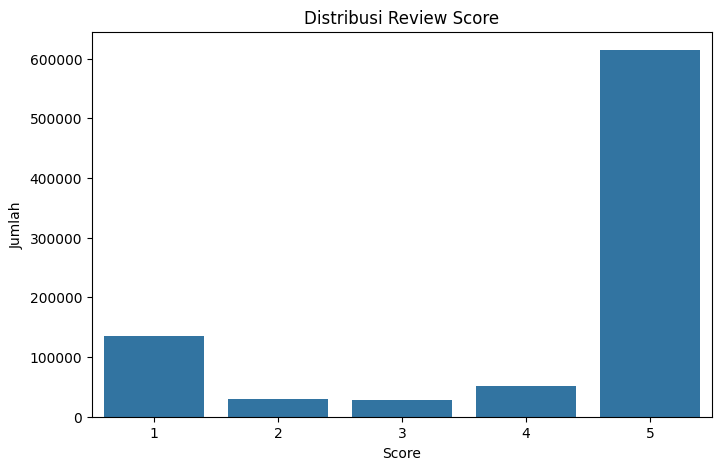

In [ ]:
# Distibusi Score
plt.figure(figsize=(8,5))
sns.countplot(x=df_brimo['score'])
plt.title("Distribusi Review Score")
plt.xlabel("Score")
plt.ylabel("Jumlah")
plt.show()

In [ ]:
# Konversi Tanggal
df_brimo['at'] = pd.to_datetime(df_brimo['at'])

# Mengambil tanggal saja
df_brimo['review_date'] = df_brimo['at'].dt.date

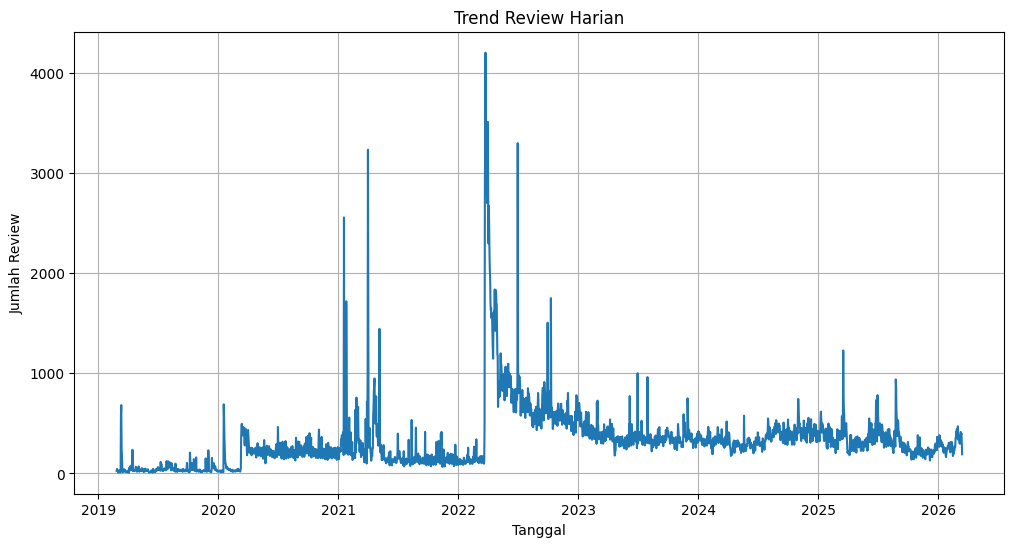

In [ ]:
# Trend Review
review_trend = df_brimo.groupby('review_date').size()

plt.figure(figsize=(12,6))
review_trend.plot()
plt.title("Trend Review Harian")
plt.xlabel("Tanggal")
plt.ylabel("Jumlah Review")
plt.grid()
plt.show()

In [ ]:
# Word Frequency
stop_words = set(stopwords.words('indonesian'))

# Menggabungkan semua text
all_reviews = " ".join(df_brimo['content'].dropna()).lower()

# Menghapus tanda baca
all_reviews = all_reviews.translate(str.maketrans("", "", string.punctuation))

# Tokenisasi
words = all_reviews.split()

# Filter stopwords
filtered_words = [word for word in words if word not in stop_words]

# Menghitung frekuensi
word_counts = Counter(filtered_words)

# Mengambil 20 kata terbanyak
common_words = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Frequency'])

print("\n=== Most Common Words ===")
print(common_words)



=== Most Common Words ===
         Word  Frequency
0       brimo     106667
1    membantu     100577
2    aplikasi      84634
3       bagus      82968
4       mudah      74359
5      mantap      71058
6   transaksi      65997
7         nya      55606
8         bri      50704
9         gak      41810
10      cepat      37511
11         yg      34171
12         ok      33567
13         ga      30361
14      login      28347
15        aja      27109
16      gagal      26941
17     daftar      26846
18       good      26021
19     banget      25054


## Tugas 1B - Sentence

In [ ]:
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
text = """Manchester is a city in the UK. It is known for football.
Many tourists visit Manchester every year."""

In [ ]:
from nltk.tokenize import sent_tokenize

sentences = sent_tokenize(text)

print("Sentences:")
print(sentences)

Sentences:
['Manchester is a city in the UK.', 'It is known for football.', 'Many tourists visit Manchester every year.']


In [ ]:
# TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(sentences)

In [ ]:
print("\nTF-IDF Matrix:")
print(tfidf_matrix.toarray())


TF-IDF Matrix:
[[0.44036207 0.         0.         0.         0.44036207 0.3349067
  0.         0.         0.3349067  0.         0.44036207 0.
  0.44036207 0.         0.        ]
 [0.         0.         0.46735098 0.46735098 0.         0.35543247
  0.46735098 0.46735098 0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.42339448 0.         0.         0.         0.
  0.         0.         0.32200242 0.42339448 0.         0.42339448
  0.         0.42339448 0.42339448]]


In [ ]:
print("\nFeature Names:")
print(vectorizer.get_feature_names_out())


Feature Names:
['city' 'every' 'football' 'for' 'in' 'is' 'it' 'known' 'manchester'
 'many' 'the' 'tourists' 'uk' 'visit' 'year']


## Tugas 1C - Replace Artikel

Link Artikel : https://finansial.bisnis.com/read/20231108/90/1712065/sustainable-loan-capai-rp253-triliun-bank-mandiri-makin-gaspol-terapkan-esg

In [ ]:
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [45]:
text = """Bank Mandiri berhasil mencetak pertumbuhan laba bersih 27,4% secara tahunan (YoY) menjadi Rp 39,1 triliun hingga kuartal III 2023. Tak hanya fokus mencetak profitabilitas yang optimal, bank bersandi saham BMRI ini konsisten mengedepankan prinsip-prinsip Environment, Social, Governance (ESG) dalam menjalani bisnis sehingga dapat menciptakan ekosistem keuangan berkelanjutan."""

sentences = sent_tokenize(text)

print("Sentences:")
print(sentences)

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(sentences)

print("\nTF-IDF Matrix:")
print(tfidf_matrix.toarray())

print("\nFeature Names:")
print(vectorizer.get_feature_names_out())

Sentences:
['Bank Mandiri berhasil mencetak pertumbuhan laba bersih 27,4% secara tahunan (YoY) menjadi Rp 39,1 triliun hingga kuartal III 2023.', 'Tak hanya fokus mencetak profitabilitas yang optimal, bank bersandi saham BMRI ini konsisten mengedepankan prinsip-prinsip Environment, Social, Governance (ESG) dalam menjalani bisnis sehingga dapat menciptakan ekosistem keuangan berkelanjutan.']

TF-IDF Matrix:
[[0.23562054 0.23562054 0.23562054 0.16764596 0.23562054 0.
  0.         0.23562054 0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.23562054 0.23562054 0.         0.         0.         0.23562054
  0.23562054 0.23562054 0.16764596 0.         0.         0.23562054
  0.         0.         0.23562054 0.         0.         0.23562054
  0.         0.23562054 0.         0.         0.23562054 0.
  0.23562054 0.         0.23562054]
 [0.         0.         0.         0.12987601 0.         0.1825362
  0.1825362  0.         0.1825362  0.182536